# Graphical Models

Graphical Models provide a framework for representing complex probability distributions using graphs.

They combine:

- Probability theory
- Graph theory
- Conditional independence
- Statistical inference
- Machine learning

A graphical model represents random variables as nodes and probabilistic relationships as edges.

The main families of graphical models are:

1. Bayesian Networks
2. Markov Random Fields
3. Gaussian Graphical Models
4. Hidden Markov Models

Graphical models are useful because they allow us to exploit structure in a probability distribution rather than treating every possible dependency independently.

## Learning Objectives

By the end of this notebook, we will understand:

- How probability distributions can be represented as graphs
- Directed and undirected graphical models
- Bayesian networks
- Conditional independence
- d-separation
- Exact probabilistic inference
- Variable elimination
- Markov Random Fields
- Gaussian graphical models
- Hidden Markov Models
- Parameter learning
- Structure learning
- Practical graphical-model implementation using Python

## 1. Why Graphical Models?

Suppose a machine-learning system contains the following random variables:

- $A$: Weather
- $B$: Traffic
- $C$: Accident
- $D$: Late arrival

A naive probabilistic model could attempt to represent the complete joint distribution:

$$
P(A,B,C,D)
$$

If every variable can take many possible values, the number of probabilities required to represent the joint distribution can become very large.

Graphical models exploit conditional independence.

For example, suppose:

$$
P(D \mid A,B,C) = P(D \mid B,C)
$$

Then weather does not need to be directly considered when predicting late arrival once traffic and accidents are known.

The graph can represent this dependency structure explicitly.

This gives us two major benefits:

1. **Compact representation**
2. **Efficient inference**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("NetworkX version:", nx.__version__)

NumPy version: 2.5.1
Pandas version: 3.0.5
NetworkX version: 3.6.1


## 2. Probability Foundations

A graphical model is fundamentally a probabilistic model.

Let random variables be:

$$
X_1, X_2, \ldots, X_n
$$

Their joint probability distribution is:

$$
P(X_1, X_2, \ldots, X_n)
$$

The joint distribution tells us the probability of combinations of values of all variables.

### Marginal Probability

If we are interested only in $X$ and not $Y$, we can marginalize over $Y$:

$$
P(X) = \sum_Y P(X,Y)
$$

For continuous variables, summation is replaced by integration:

$$
P(X) = \int P(X,Y)\,dY
$$

### Conditional Probability

The conditional probability of $X$ given $Y$ is:

$$
P(X\mid Y)
=
\frac{P(X,Y)}{P(Y)}
$$

### Bayes' Rule

Bayes' rule gives:

$$
P(X\mid Y)
=
\frac{P(Y\mid X)P(X)}
{P(Y)}
$$

Graphical models use these fundamental probability operations to perform inference.

## 3. Conditional Independence

Conditional independence is one of the most important ideas in graphical models.

Two variables $X$ and $Y$ are conditionally independent given $Z$ if:

$$
P(X,Y\mid Z)
=
P(X\mid Z)P(Y\mid Z)
$$

We write:

$$
X \perp Y \mid Z
$$

This means that once $Z$ is known, information about $Y$ provides no additional information about $X$.

### Example

Suppose:

- $R$: Rain
- $T$: Traffic
- $L$: Late arrival

We may have:

$$
R \rightarrow T \rightarrow L
$$

Once traffic is known, knowing whether it rained may provide little additional information about whether someone is late.

Therefore:

$$
R \perp L \mid T
$$

Graphical models make such independence assumptions explicit through graph structure.

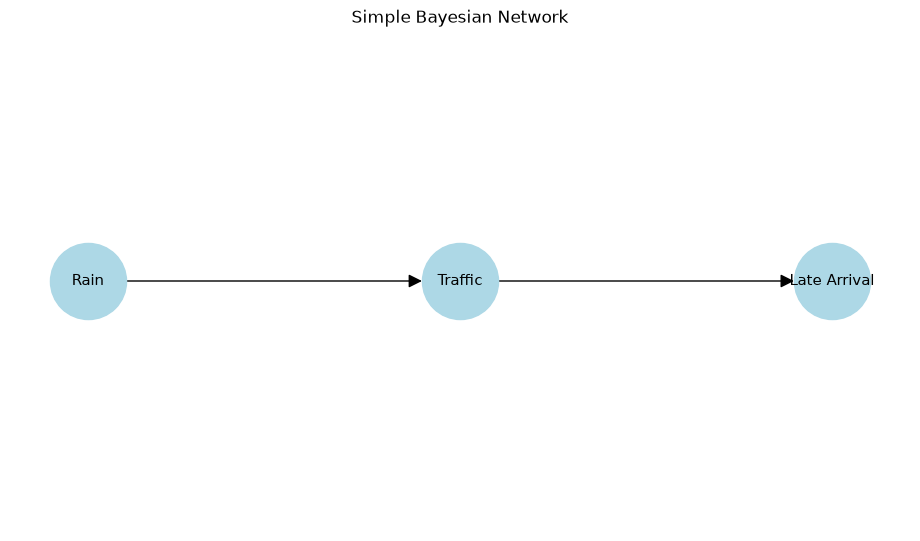

In [2]:
# Simple directed graph illustrating conditional dependence

G = nx.DiGraph()

G.add_edges_from([
    ("Rain", "Traffic"),
    ("Traffic", "Late Arrival")
])

plt.figure(figsize=(9, 5))

pos = {
    "Rain": (0, 0),
    "Traffic": (1, 0),
    "Late Arrival": (2, 0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    arrows=True,
    arrowsize=20,
    font_size=11
)

plt.title("Simple Bayesian Network")
plt.axis("off")
plt.show()

## 4. Directed vs. Undirected Graphical Models

Graphical models can broadly be divided into two categories.

### Directed Graphical Models

A directed graphical model uses directed edges.

The most important example is the:

**Bayesian Network**

For example:

$$
A \rightarrow B \rightarrow C
$$

The arrows represent conditional dependencies.

The joint distribution can be factorized according to the graph.

### Undirected Graphical Models

An undirected graphical model uses edges without arrows.

The most important example is the:

**Markov Random Field (MRF)**

For example:

$$
A - B - C
$$

Undirected models are often useful when relationships are symmetric rather than naturally causal.

### Comparison

| Property | Bayesian Network | Markov Random Field |
|---|---|---|
| Graph | Directed | Undirected |
| Main structure | DAG | Undirected graph |
| Factorization | Conditional probabilities | Potential functions |
| Independence concept | d-separation | Graph separation |
| Common use | Causal/probabilistic relationships | Spatial/contextual relationships |

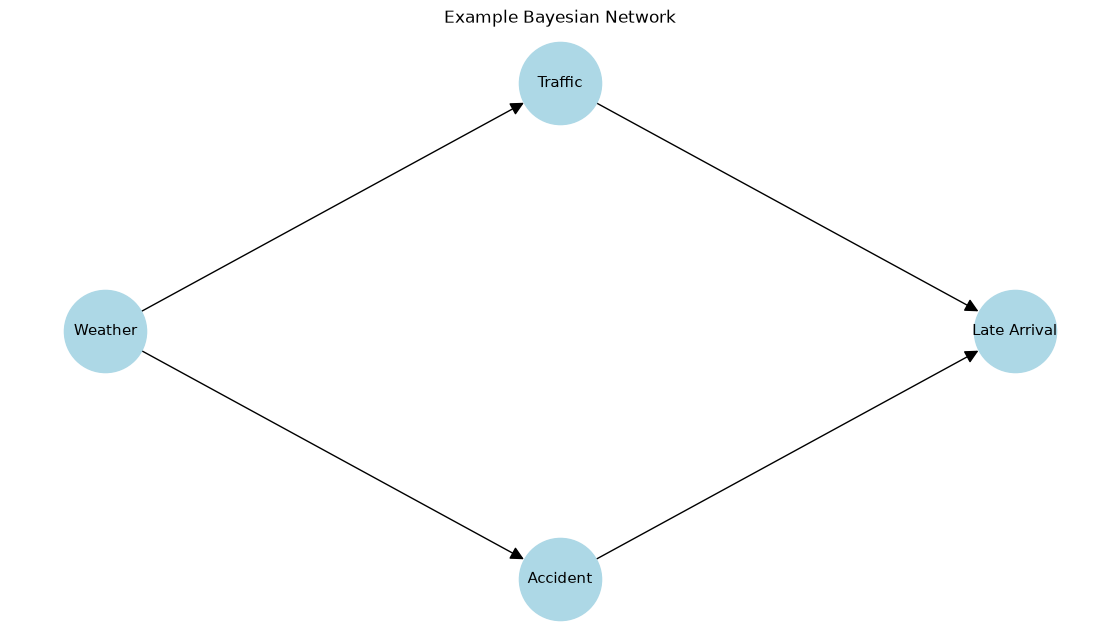

In [3]:
bn = nx.DiGraph()

bn.add_edges_from([
    ("Weather", "Traffic"),
    ("Weather", "Accident"),
    ("Traffic", "Late Arrival"),
    ("Accident", "Late Arrival")
])

plt.figure(figsize=(11, 6))

pos = {
    "Weather": (0, 1),
    "Traffic": (1, 2),
    "Accident": (1, 0),
    "Late Arrival": (2, 1)
}

nx.draw(
    bn,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    arrows=True,
    arrowsize=20,
    font_size=11
)

plt.title("Example Bayesian Network")
plt.axis("off")
plt.show()

### Factorization of the Example Network

The graph contains:

$$
Weather \rightarrow Traffic
$$

$$
Weather \rightarrow Accident
$$

$$
Traffic \rightarrow LateArrival
$$

$$
Accident \rightarrow LateArrival
$$

Therefore:

$$
P(W,T,A,L)
=
P(W)
P(T\mid W)
P(A\mid W)
P(L\mid T,A)
$$

Instead of directly specifying one large joint distribution, we specify smaller local conditional distributions.

This is the key advantage of Bayesian Networks.

## 6. Conditional Probability Tables

For discrete Bayesian Networks, relationships can be represented using Conditional Probability Tables (CPTs).

Suppose:

$$
Rain \rightarrow Traffic
$$

Both variables are binary.

For example:

| Rain | $P(Traffic=High\mid Rain)$ |
|---|---:|
| Yes | 0.90 |
| No | 0.20 |

The probability of low traffic is obtained from:

$$
P(Traffic=Low\mid Rain)
=
1-P(Traffic=High\mid Rain)
$$

Therefore:

| Rain | High Traffic | Low Traffic |
|---|---:|---:|
| Yes | 0.90 | 0.10 |
| No | 0.20 | 0.80 |

A Bayesian Network is therefore composed of both:

1. **Graph structure**
2. **Local probability distributions**

In [4]:
traffic_cpt = pd.DataFrame(
    {
        "High Traffic": [0.90, 0.20],
        "Low Traffic": [0.10, 0.80]
    },
    index=["Rain", "No Rain"]
)

traffic_cpt

,High Traffic,Low Traffic
Rain,0.9,0.1
No Rain,0.2,0.8


## 7. Conditional Independence in a Bayesian Network

Consider the structure:

$$
A \rightarrow B \rightarrow C
$$

This represents a chain.

The graph implies:

$$
A \perp C \mid B
$$

In other words, after observing $B$, $A$ and $C$ become conditionally independent.

The three fundamental structures we need to understand are:

### Chain

$$
A \rightarrow B \rightarrow C
$$

### Fork

$$
A \leftarrow B \rightarrow C
$$

### Collider

$$
A \rightarrow B \leftarrow C
$$

These structures behave differently under conditioning.

Understanding them is essential for **d-separation**.

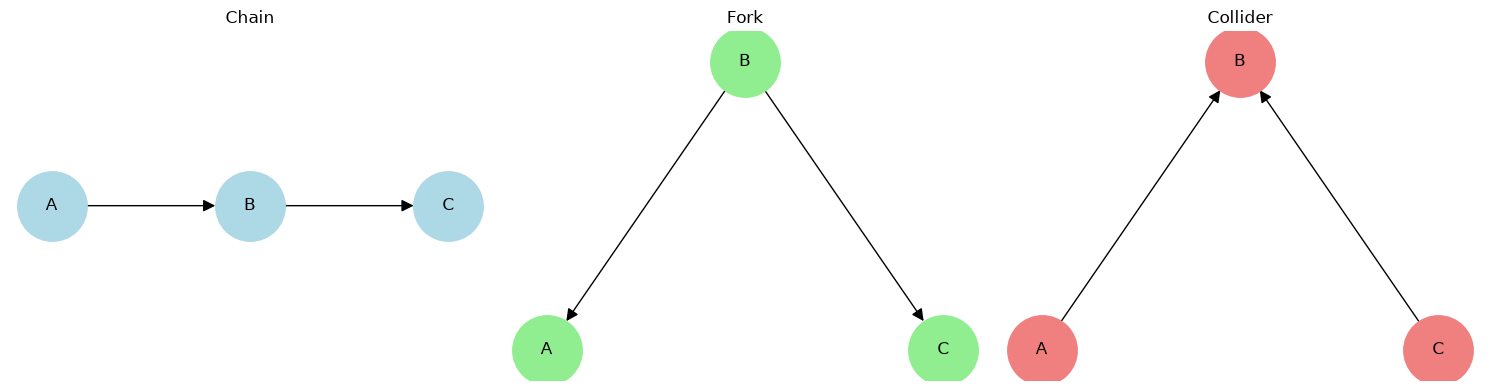

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chain
chain = nx.DiGraph([
    ("A", "B"),
    ("B", "C")
])

nx.draw(
    chain,
    pos={"A": (0, 0), "B": (1, 0), "C": (2, 0)},
    ax=axes[0],
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    arrows=True,
    arrowsize=18
)
axes[0].set_title("Chain")
axes[0].axis("off")

# Fork
fork = nx.DiGraph([
    ("B", "A"),
    ("B", "C")
])

nx.draw(
    fork,
    pos={"A": (0, 0), "B": (1, 1), "C": (2, 0)},
    ax=axes[1],
    with_labels=True,
    node_size=2500,
    node_color="lightgreen",
    arrows=True,
    arrowsize=18
)
axes[1].set_title("Fork")
axes[1].axis("off")

# Collider
collider = nx.DiGraph([
    ("A", "B"),
    ("C", "B")
])

nx.draw(
    collider,
    pos={"A": (0, 0), "B": (1, 1), "C": (2, 0)},
    ax=axes[2],
    with_labels=True,
    node_size=2500,
    node_color="lightcoral",
    arrows=True,
    arrowsize=18
)
axes[2].set_title("Collider")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 8. d-Separation

d-separation is a graphical criterion used to determine conditional independence in a Bayesian Network.

It allows us to answer questions such as:

> Are $X$ and $Y$ conditionally independent given $Z$?

without explicitly calculating the probability distribution.

### Chain

$$
A \rightarrow B \rightarrow C
$$

Conditioning on $B$ blocks the path:

$$
A \perp C \mid B
$$

### Fork

$$
A \leftarrow B \rightarrow C
$$

Conditioning on the common cause $B$ blocks the association:

$$
A \perp C \mid B
$$

### Collider

$$
A \rightarrow B \leftarrow C
$$

A collider behaves differently.

Without conditioning on $B$:

$$
A \perp C
$$

But conditioning on the collider can create statistical dependence:

$$
A \not\perp C \mid B
$$

This phenomenon is extremely important in causal modeling and feature selection.

> **Important:** Correlation created by conditioning on a collider is often called **collider bias** or **selection bias**.

# 9. Bayesian Network Inference

Inference means computing unknown probabilities from observed evidence.

Suppose we want:

$$
P(LateArrival \mid Rain)
$$

A Bayesian Network can combine information from several connected variables to answer this query.

A general posterior query has the form:

$$
P(X\mid E)
$$

where:

- $X$ is the query variable
- $E$ is observed evidence

Inference can be performed using methods such as:

- Enumeration
- Variable elimination
- Belief propagation
- Sampling-based inference

We will implement exact inference before moving to more advanced methods.

In [6]:
# Simple exact inference example

p_rain = {
    True: 0.30,
    False: 0.70
}

p_traffic_high_given_rain = {
    True: 0.90,
    False: 0.20
}

p_late_given_traffic = {
    True: 0.80,
    False: 0.10
}

prob_late = 0

for rain in [True, False]:
    for traffic_high in [True, False]:
        p_traffic = (
            p_traffic_high_given_rain[rain]
            if traffic_high
            else 1 - p_traffic_high_given_rain[rain]
        )

        p_late_value = (
            p_late_given_traffic[traffic_high]
            if traffic_high
            else 1 - p_late_given_traffic[traffic_high]
        )

        prob_late += (
            p_rain[rain]
            * p_traffic
            * p_late_value
        )

prob_late

0.859

The previous calculation performs **enumeration**.

We sum over the hidden variable `Rain` and `Traffic`:

$$
P(L)
=
\sum_R\sum_T
P(R)P(T\mid R)P(L\mid T)
$$

This works well for small networks.

However, enumeration becomes computationally expensive as the number of variables grows.

This motivates more efficient inference algorithms such as **variable elimination**.

## 10. Variable Elimination

Variable elimination avoids repeatedly calculating unnecessary parts of the joint distribution.

Suppose:

$$
P(X,Y,Z)
=
P(X)P(Y\mid X)P(Z\mid Y)
$$

and we want:

$$
P(Z)
$$

We can eliminate $X$ first:

$$
P(Z)
=
\sum_Y
\left[
P(Z\mid Y)
\sum_X P(X)P(Y\mid X)
\right]
$$

The inner summation produces an intermediate factor.

This approach can dramatically reduce computational work.

The efficiency of variable elimination depends heavily on the graph structure and the order in which variables are eliminated.

# 11. Markov Random Fields

A Markov Random Field (MRF) is an undirected graphical model.

Consider:

$$
A-B-C
$$

The graph describes conditional relationships between variables.

Unlike Bayesian Networks, MRFs do not use directed conditional probability edges.

Instead, they use **potential functions**.

A general MRF distribution can be written as:

$$
P(X)
=
\frac{1}{Z}
\prod_{C}
\psi_C(X_C)
$$

where:

- $\psi_C$ is a potential function
- $X_C$ represents variables in clique $C$
- $Z$ is the partition function

The partition function ensures that probabilities sum to one:

$$
Z
=
\sum_X
\prod_C \psi_C(X_C)
$$

MRFs are particularly useful for problems involving spatial or symmetric relationships.

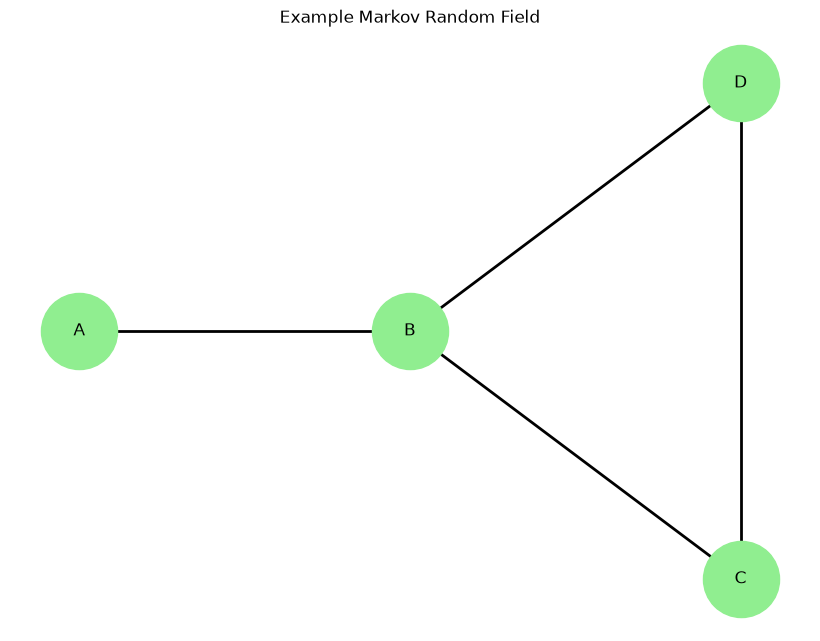

In [7]:
mrf = nx.Graph()

mrf.add_edges_from([
    ("A", "B"),
    ("B", "C"),
    ("B", "D"),
    ("C", "D")
])

plt.figure(figsize=(8, 6))

pos = {
    "A": (0, 1),
    "B": (1, 1),
    "C": (2, 0),
    "D": (2, 2)
}

nx.draw(
    mrf,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightgreen",
    font_size=12,
    width=2
)

plt.title("Example Markov Random Field")
plt.axis("off")
plt.show()

# 12. Gaussian Graphical Models

Gaussian Graphical Models (GGMs) represent relationships among continuous variables using a multivariate Gaussian distribution.

Let:

$$
X \sim \mathcal{N}(\mu,\Sigma)
$$

where:

- $\mu$ is the mean vector
- $\Sigma$ is the covariance matrix

The precision matrix is:

$$
\Theta = \Sigma^{-1}
$$

One important property of Gaussian Graphical Models is:

$$
\Theta_{ij}=0
\iff
X_i \perp X_j
\mid X_{\setminus\{i,j\}}
$$

Therefore, zeros in the precision matrix correspond to conditional independencies.

This gives a direct connection between:

- Linear algebra
- Probability
- Graph structure

In [8]:
from sklearn.covariance import GraphicalLasso

rng = np.random.default_rng(42)

X = rng.multivariate_normal(
    mean=np.zeros(4),
    cov=np.array([
        [1.0, 0.7, 0.2, 0.0],
        [0.7, 1.0, 0.5, 0.1],
        [0.2, 0.5, 1.0, 0.6],
        [0.0, 0.1, 0.6, 1.0]
    ]),
    size=500
)

model = GraphicalLasso(alpha=0.1)
model.fit(X)

precision_matrix = model.precision_

pd.DataFrame(
    precision_matrix,
    columns=["X1", "X2", "X3", "X4"],
    index=["X1", "X2", "X3", "X4"]
)

,X1,X2,X3,X4
X1,1.420469,-0.845546,0.000000,0.038002
X2,-0.845546,1.730050,-0.504233,0.099106
X3,0.000000,-0.504233,1.622201,-0.734559
X4,0.038002,0.099106,-0.734559,1.314253


# 13. Hidden Markov Models

A Hidden Markov Model (HMM) is a probabilistic model containing:

- Hidden states
- Observations
- Transition probabilities
- Emission probabilities

The basic structure is:

$$
S_1 \rightarrow S_2 \rightarrow S_3 \rightarrow \cdots
$$

with observations:

$$
O_1,\ O_2,\ O_3,\ldots
$$

generated from the hidden states.

The model assumes that the current state depends primarily on the previous state:

$$
P(S_t\mid S_1,\ldots,S_{t-1})
=
P(S_t\mid S_{t-1})
$$

The observation depends on the current hidden state:

$$
P(O_t\mid S_1,\ldots,S_t,O_1,\ldots,O_{t-1})
=
P(O_t\mid S_t)
$$

HMMs are widely used in:

- Speech recognition
- Natural language processing
- Bioinformatics
- Time-series modeling
- Sequence analysis

In [9]:
states = ["Sunny", "Rainy"]
observations = ["Walk", "Shop", "Clean"]

transition = pd.DataFrame(
    [
        [0.8, 0.2],
        [0.3, 0.7]
    ],
    index=states,
    columns=states
)

emission = pd.DataFrame(
    [
        [0.6, 0.3, 0.1],
        [0.1, 0.4, 0.5]
    ],
    index=states,
    columns=observations
)

print("Transition probabilities:")
display(transition)

print("Emission probabilities:")
display(emission)

Transition probabilities:


,Sunny,Rainy
Sunny,0.8,0.2
Rainy,0.3,0.7


Emission probabilities:


,Walk,Shop,Clean
Sunny,0.6,0.3,0.1
Rainy,0.1,0.4,0.5


## 14. Forward Algorithm

The Forward Algorithm computes the probability of an observation sequence.

Define:

$$
\alpha_t(i)
=
P(O_1,\ldots,O_t,S_t=i)
$$

The initialization step is:

$$
\alpha_1(i)
=
P(S_1=i)P(O_1\mid S_1=i)
$$

The recursive step is:

$$
\alpha_t(j)
=
P(O_t\mid S_t=j)
\sum_i
\alpha_{t-1}(i)
P(S_t=j\mid S_{t-1}=i)
$$

This allows us to calculate sequence probabilities efficiently without enumerating every possible state sequence.

In [10]:
initial = {
    "Sunny": 0.6,
    "Rainy": 0.4
}

sequence = ["Walk", "Shop", "Clean"]

alpha = {}

for state in states:
    alpha[state] = (
        initial[state]
        * emission.loc[state, sequence[0]]
    )

forward_history = [alpha.copy()]

for observation in sequence[1:]:
    new_alpha = {}

    for current_state in states:
        total = sum(
            alpha[previous_state]
            * transition.loc[previous_state, current_state]
            for previous_state in states
        )

        new_alpha[current_state] = (
            total
            * emission.loc[current_state, observation]
        )

    alpha = new_alpha
    forward_history.append(alpha.copy())

forward_history

[{'Sunny': np.float64(0.36), 'Rainy': np.float64(0.04000000000000001)},
 {'Sunny': np.float64(0.09), 'Rainy': np.float64(0.04000000000000001)},
 {'Sunny': np.float64(0.0084), 'Rainy': np.float64(0.023)}]

## 15. Viterbi Algorithm

The Forward Algorithm calculates the probability of an observation sequence.

The **Viterbi Algorithm** instead finds the most likely hidden-state sequence.

Given observations:

$$
O_1,O_2,\ldots,O_T
$$

we want:

$$
\arg\max_{S_1,\ldots,S_T}
P(S_1,\ldots,S_T\mid O_1,\ldots,O_T)
$$

The Viterbi algorithm uses dynamic programming to avoid enumerating every possible state sequence.

This makes it practical for long sequences.

In [11]:
def viterbi(sequence, states, transition, emission, initial):
    delta = {}
    paths = {}

    first_observation = sequence[0]

    for state in states:
        delta[state] = (
            initial[state]
            * emission.loc[state, first_observation]
        )
        paths[state] = [state]

    for observation in sequence[1:]:
        new_delta = {}
        new_paths = {}

        for current_state in states:
            candidates = [
                (
                    delta[previous_state]
                    * transition.loc[previous_state, current_state]
                    * emission.loc[current_state, observation],
                    previous_state
                )
                for previous_state in states
            ]

            best_probability, best_previous = max(
                candidates,
                key=lambda x: x[0]
            )

            new_delta[current_state] = best_probability
            new_paths[current_state] = (
                paths[best_previous] + [current_state]
            )

        delta = new_delta
        paths = new_paths

    best_state = max(delta, key=delta.get)

    return paths[best_state], delta[best_state]


best_path, probability = viterbi(
    sequence,
    states,
    transition,
    emission,
    initial
)

print("Observation sequence:", sequence)
print("Most likely hidden states:", best_path)
print("Probability:", probability)

Observation sequence: ['Walk', 'Shop', 'Clean']
Most likely hidden states: ['Sunny', 'Rainy', 'Rainy']
Probability: 0.010079999999999999


# 16. Practical Bayesian Network with `pgmpy`

For practical probabilistic graphical modeling, we can use the Python package `pgmpy`.

It provides tools for:

- Bayesian Networks
- Markov Networks
- Conditional Probability Distributions
- Exact inference
- Approximate inference
- Parameter estimation
- Structure learning

We will construct a small Bayesian Network and perform probabilistic inference.

In [12]:
# Run this cell if pgmpy is already installed.
# Otherwise install it from your terminal with:
# pip install pgmpy

import pgmpy

print("pgmpy version:", pgmpy.__version__)

pgmpy version: 1.1.2


In [13]:
from pgmpy.models import DiscreteBayesianNetwork

model = DiscreteBayesianNetwork([
    ("Rain", "Traffic"),
    ("Traffic", "Late")
])

model.nodes()

NodeView(('Rain', 'Traffic', 'Late'))

In [14]:
from pgmpy.factors.discrete import TabularCPD

cpd_rain = TabularCPD(
    variable="Rain",
    variable_card=2,
    values=[[0.7], [0.3]]
)

cpd_traffic = TabularCPD(
    variable="Traffic",
    variable_card=2,
    values=[
        [0.8, 0.2],
        [0.2, 0.8]
    ],
    evidence=["Rain"],
    evidence_card=[2]
)

cpd_late = TabularCPD(
    variable="Late",
    variable_card=2,
    values=[
        [0.9, 0.3],
        [0.1, 0.7]
    ],
    evidence=["Traffic"],
    evidence_card=[2]
)

model.add_cpds(
    cpd_rain,
    cpd_traffic,
    cpd_late
)

model.check_model()

True

In [15]:
for cpd in model.get_cpds():
    print(cpd)
    print()

+---------+-----+
| Rain(0) | 0.7 |
+---------+-----+
| Rain(1) | 0.3 |
+---------+-----+

+------------+---------+---------+
| Rain       | Rain(0) | Rain(1) |
+------------+---------+---------+
| Traffic(0) | 0.8     | 0.2     |
+------------+---------+---------+
| Traffic(1) | 0.2     | 0.8     |
+------------+---------+---------+

+---------+------------+------------+
| Traffic | Traffic(0) | Traffic(1) |
+---------+------------+------------+
| Late(0) | 0.9        | 0.3        |
+---------+------------+------------+
| Late(1) | 0.1        | 0.7        |
+---------+------------+------------+



In [16]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

result = inference.query(
    variables=["Late"],
    evidence={"Rain": 1}
)

print(result)

d:\Python\Python_Learning\.env\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


+---------+-------------+
| Late    |   phi(Late) |
+=========+=============+
| Late(0) |      0.4200 |
+---------+-------------+
| Late(1) |      0.5800 |
+---------+-------------+


## Visualizing the Bayesian Network

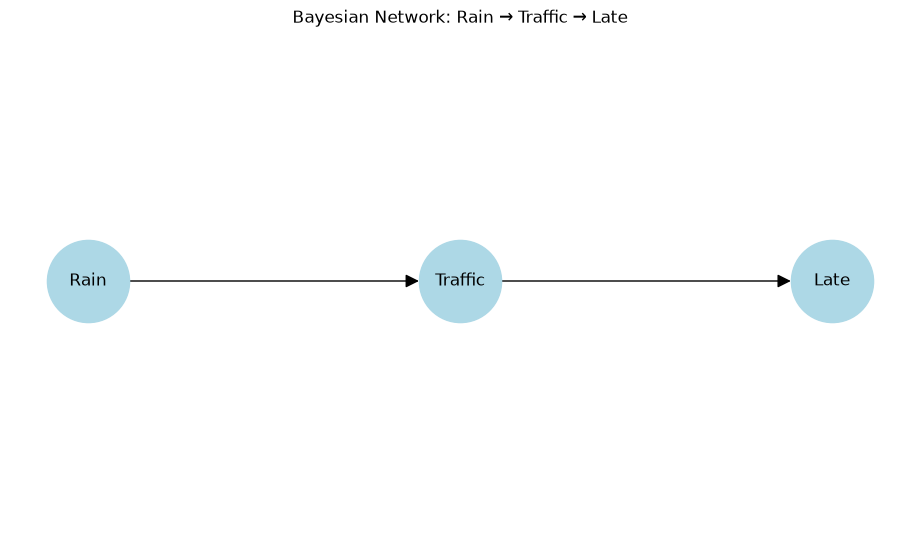

In [17]:
plt.figure(figsize=(9, 5))

pos = {
    "Rain": (0, 0),
    "Traffic": (1, 0),
    "Late": (2, 0)
}

nx.draw(
    model,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    arrows=True,
    arrowsize=20,
    font_size=12
)

plt.title("Bayesian Network: Rain → Traffic → Late")
plt.axis("off")
plt.show()

# 18. Parameter Learning

A graphical model has two major components:

1. **Structure**
2. **Parameters**

Suppose the structure is already known:

$$
Rain \rightarrow Traffic \rightarrow Late
$$

We still need to estimate:

$$
P(Rain)
$$

$$
P(Traffic\mid Rain)
$$

$$
P(Late\mid Traffic)
$$

from data.

For discrete Bayesian Networks, maximum-likelihood estimation can estimate these conditional distributions from observed data.

The general idea is:

$$
\hat{\theta}
=
\arg\max_{\theta}
P(D\mid\theta)
$$

where:

- $D$ is the observed dataset
- $\theta$ represents model parameters

In [18]:
rng = np.random.default_rng(42)

n = 1000

data = pd.DataFrame({
    "Rain": rng.binomial(1, 0.3, n)
})

data["Traffic"] = [
    rng.binomial(1, 0.8 if rain else 0.2)
    for rain in data["Rain"]
]

data["Late"] = [
    rng.binomial(1, 0.8 if traffic else 0.1)
    for traffic in data["Traffic"]
]

data.head()

,Rain,Traffic,Late
0,1,1,0
1,0,0,0
2,1,1,0
3,0,0,0
4,0,0,0


In [27]:
from pgmpy.models import DiscreteBayesianNetwork

learned_model = DiscreteBayesianNetwork([
    ("Rain", "Traffic"),
    ("Traffic", "Late")
])

learned_model.fit(data)

learned_model.check_model()

for cpd in learned_model.get_cpds():
    print(cpd)
    print()

+---------+-------+
| Rain(0) | 0.696 |
+---------+-------+
| Rain(1) | 0.304 |
+---------+-------+

+------------+---------------------+--------------------+
| Rain       | Rain(0)             | Rain(1)            |
+------------+---------------------+--------------------+
| Traffic(0) | 0.7830459770114943  | 0.2138157894736842 |
+------------+---------------------+--------------------+
| Traffic(1) | 0.21695402298850575 | 0.7861842105263158 |
+------------+---------------------+--------------------+

+---------+---------------------+---------------------+
| Traffic | Traffic(0)          | Traffic(1)          |
+---------+---------------------+---------------------+
| Late(0) | 0.9065573770491804  | 0.18974358974358974 |
+---------+---------------------+---------------------+
| Late(1) | 0.09344262295081968 | 0.8102564102564103  |
+---------+---------------------+---------------------+



# 19. Structure Learning

In many real-world problems, the graph structure itself is unknown.

We may observe data:

$$
D = \{x_1,x_2,\ldots,x_n\}
$$

and want to discover a suitable graph.

This is called **structure learning**.

Two broad approaches are:

### Constraint-Based Learning

Uses conditional-independence tests to infer graph structure.

Examples include:

- PC algorithm
- Constraint-based search

### Score-Based Learning

Searches over possible graphs and evaluates them using a score.

Common scores include:

- Bayesian Information Criterion (BIC)
- Akaike Information Criterion (AIC)
- Bayesian Dirichlet equivalent (BDe)

The problem can be expressed as:

$$
G^*
=
\arg\max_G
Score(G,D)
$$

Structure learning can be computationally difficult because the number of possible graph structures grows rapidly as the number of variables increases.

# 20. Graphical Models and Causality

Graphical models are closely related to causal inference, but a graphical relationship should not automatically be interpreted as causal.

For example:

$$
X \rightarrow Y
$$

may represent a causal hypothesis, but the graph itself does not prove that $X$ causes $Y$.

Causal graphical models introduce additional assumptions about how variables generate one another.

Important concepts include:

- Confounding
- Intervention
- Backdoor paths
- Collider bias
- Causal effects
- Counterfactual reasoning

An intervention is often written using Pearl's notation:

$$
P(Y\mid do(X=x))
$$

This is different from ordinary conditioning:

$$
P(Y\mid X=x)
$$

Understanding this distinction is essential when using graphical models for causal reasoning.

# 21. Applications of Graphical Models

Graphical models appear in many areas of computer science and machine learning.

### Natural Language Processing

HMMs and related graphical models have historically been used for:

- Part-of-speech tagging
- Speech recognition
- Sequence modeling

### Computer Vision

MRFs and Conditional Random Fields have been used for:

- Image segmentation
- Object recognition
- Denoising
- Pixel-label prediction

### Bioinformatics

Graphical models can represent:

- Gene relationships
- Protein interactions
- DNA sequences
- Biological pathways

### Robotics

Graphical models support:

- Localization
- Mapping
- Sensor fusion
- State estimation

### Medical Decision Systems

Bayesian Networks can represent probabilistic relationships between:

- Symptoms
- Diseases
- Tests
- Treatments

### Time-Series Modeling

HMMs and dynamic Bayesian networks model evolving hidden states.

# 22. Graphical Models vs Other Machine Learning Models

| Model | Main Strength | Interpretability | Probabilistic Structure |
|---|---|---:|---:|
| Linear Regression | Simple relationships | High | Limited |
| Decision Tree | Rule-based decisions | High | Limited |
| Random Forest | Strong tabular prediction | Medium | Limited |
| Neural Network | Complex nonlinear patterns | Low | Usually implicit |
| Bayesian Network | Dependencies + inference | High | Explicit |
| Markov Random Field | Structured dependencies | High | Explicit |
| Hidden Markov Model | Sequential hidden states | High | Explicit |

Graphical models are particularly valuable when we care about **relationships and uncertainty**, rather than only predictive accuracy.

# 23. End-to-End Case Study

We will construct a simple probabilistic model:

$$
Weather \rightarrow Traffic
$$

$$
Weather \rightarrow Accident
$$

$$
Traffic \rightarrow Late
$$

$$
Accident \rightarrow Late
$$

Our goal is to answer:

> What is the probability of being late given that it is raining?

The workflow is:

1. Define the graph
2. Define probability distributions
3. Validate the model
4. Visualize the network
5. Perform inference
6. Interpret the posterior probability

In [20]:
case_model = DiscreteBayesianNetwork([
    ("Weather", "Traffic"),
    ("Weather", "Accident"),
    ("Traffic", "Late"),
    ("Accident", "Late")
])

cpd_weather = TabularCPD(
    variable="Weather",
    variable_card=2,
    values=[[0.7], [0.3]]
)

cpd_traffic = TabularCPD(
    variable="Traffic",
    variable_card=2,
    values=[
        [0.8, 0.3],
        [0.2, 0.7]
    ],
    evidence=["Weather"],
    evidence_card=[2]
)

cpd_accident = TabularCPD(
    variable="Accident",
    variable_card=2,
    values=[
        [0.95, 0.75],
        [0.05, 0.25]
    ],
    evidence=["Weather"],
    evidence_card=[2]
)

cpd_late = TabularCPD(
    variable="Late",
    variable_card=2,
    values=[
        [0.95, 0.60, 0.70, 0.20],
        [0.05, 0.40, 0.30, 0.80]
    ],
    evidence=["Traffic", "Accident"],
    evidence_card=[2, 2]
)

case_model.add_cpds(
    cpd_weather,
    cpd_traffic,
    cpd_accident,
    cpd_late
)

case_model.check_model()

True

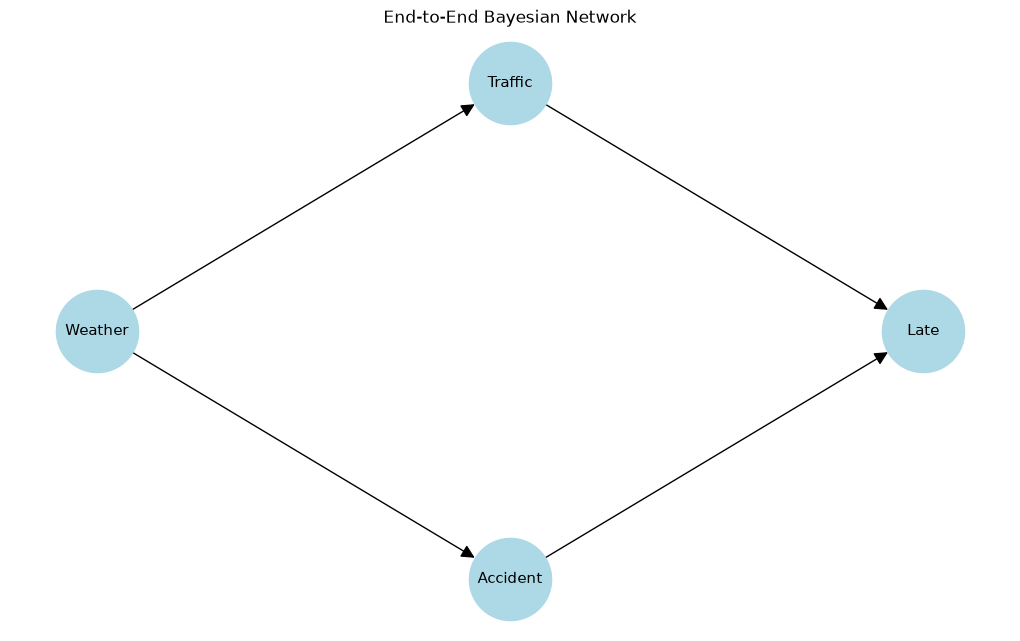

In [21]:
plt.figure(figsize=(10, 6))

pos = {
    "Weather": (0, 1),
    "Traffic": (1, 2),
    "Accident": (1, 0),
    "Late": (2, 1)
}

nx.draw(
    case_model,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    arrows=True,
    arrowsize=20,
    font_size=11
)

plt.title("End-to-End Bayesian Network")
plt.axis("off")
plt.show()

In [22]:
case_inference = VariableElimination(case_model)

posterior = case_inference.query(
    variables=["Late"],
    evidence={"Weather": 1}
)

print(posterior)

+---------+-------------+
| Late    |   phi(Late) |
+=========+=============+
| Late(0) |      0.6613 |
+---------+-------------+
| Late(1) |      0.3388 |
+---------+-------------+


### Interpretation

The inference engine combines:

$$
P(Late\mid Traffic,Accident)
$$

with:

$$
P(Traffic\mid Weather)
$$

and:

$$
P(Accident\mid Weather)
$$

to calculate:

$$
P(Late\mid Weather)
$$

This illustrates the main purpose of graphical models:

> Represent a complex probability distribution using a structured graph and use that structure to perform efficient reasoning under uncertainty.

# 24. Key Takeaways

The most important concepts from this notebook are:

### 1. Graphical Representation

Random variables are represented as nodes and dependencies as edges.

### 2. Conditional Independence

Graph structure can encode independence assumptions:

$$
X \perp Y \mid Z
$$

### 3. Bayesian Networks

Directed acyclic graphs represent conditional probability relationships.

Their joint distribution factorizes as:

$$
P(X_1,\ldots,X_n)
=
\prod_i P(X_i\mid Pa(X_i))
$$

### 4. d-Separation

d-separation provides a graphical method for determining conditional independence.

### 5. Markov Random Fields

MRFs use undirected graphs and potential functions:

$$
P(X)
=
\frac{1}{Z}
\prod_C \psi_C(X_C)
$$

### 6. Gaussian Graphical Models

The precision matrix reveals conditional independence relationships.

### 7. Hidden Markov Models

HMMs represent sequences with hidden states and observations.

Important algorithms include:

- Forward algorithm
- Viterbi algorithm

### 8. Learning

Graphical models can learn:

- Parameters
- Graph structures

### 9. Inference

Inference allows us to compute unknown probabilities from observed evidence.

### 10. Causality

Graphical models provide an important foundation for reasoning about causal relationships, but causal interpretation requires additional assumptions.